Video Presentasi: https://drive.google.com/drive/folders/1gLXtv3GgQXTTP5_JKsIrGJ3qbs54DRni?usp=sharing 

Ivan William Lianata - 2802461776

### Nomor 2: Dimension Reduction dengan Autoencoder


## Import Libraries & Configuration

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

try:
    from IPython.display import display
except ImportError:
    display = print

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

FIGDIR = Path('figures_v2')
FIGDIR.mkdir(exist_ok=True)

def save_and_show(fig, name):
    fig.savefig(FIGDIR / f'{name}.png', dpi=110, bbox_inches='tight')
    plt.show()
    plt.close(fig)

In [1]:
DATASET_DIR = Path('version2')

CLASS_NAMES  = ['storage_tank', 'parking_lot']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}

IMG_SIZE    = (28, 28)
LATENT_DIM  = 128
BATCH_SIZE  = 32
EPOCHS_BASE = 100
EPOCHS_MOD  = 100

print(f'Dataset dir : {DATASET_DIR.resolve()}')
print(f'Classes     : {CLASS_NAMES}')
print(f'Image size  : {IMG_SIZE}')
print(f'Latent dim  : {LATENT_DIM}', flush=True)

Dataset dir : D:\Semester IV\Deep Learning\UAS\Nomor 2\version2
Classes     : ['storage_tank', 'parking_lot']
Image size  : (28, 28)
Latent dim  : 128


## A. Data Preparation
### A.1 Load Data

In [1]:
VALID_EXT = {'.jpg', '.jpeg'}
records = []

for split in ['train', 'test']:
    for class_name in CLASS_NAMES:
        class_dir = DATASET_DIR / split / class_name
        files = [f for f in class_dir.iterdir() if f.suffix.lower() in VALID_EXT]

        print(f'  {split:9s} {class_name:15s}: {len(files):>4} gambar')

        for f in files:
            records.append({
                'path': str(f),
                'label': CLASS_LABELS[class_name],
                'class_name': class_name
            })

df_meta = pd.DataFrame(records)
print(f'\nTotal gambar: {len(df_meta)}', flush=True)
print(df_meta.head())

  train     storage_tank   : 7121 gambar
  train     parking_lot    : 7111 gambar
  test      storage_tank   :  888 gambar
  test      parking_lot    :  896 gambar

Total gambar: 16016
                                    path  label    class_name
0  version2\train\storage_tank\00001.jpg      0  storage_tank
1  version2\train\storage_tank\00005.jpg      0  storage_tank
2  version2\train\storage_tank\00022.jpg      0  storage_tank
3  version2\train\storage_tank\00033.jpg      0  storage_tank
4  version2\train\storage_tank\00045.jpg      0  storage_tank


Folder `train/` dan `test/` bawaan dataset digabung menjadi satu pool, agar
pembagian data sendiri (80% train, 10% validation, 10% test)

### A.2 Scaling & Contoh Data

In [1]:
def load_images(paths, img_size=IMG_SIZE):
    images = np.zeros((len(paths), img_size[0], img_size[1], 1), dtype=np.float32)

    for i, p in enumerate(paths):
        img = Image.open(p).convert('L').resize(img_size)
        images[i, ..., 0] = np.array(img, dtype=np.float32)

    return images / 255.0  # scaling ke rentang [0, 1]


X = load_images(df_meta['path'].values)
y = df_meta['label'].values

print(f'X shape : {X.shape}')
print(f'Range   : [{X.min():.3f}, {X.max():.3f}]', flush=True)

X shape : (16016, 28, 28, 1)
Range   : [0.000, 1.000]


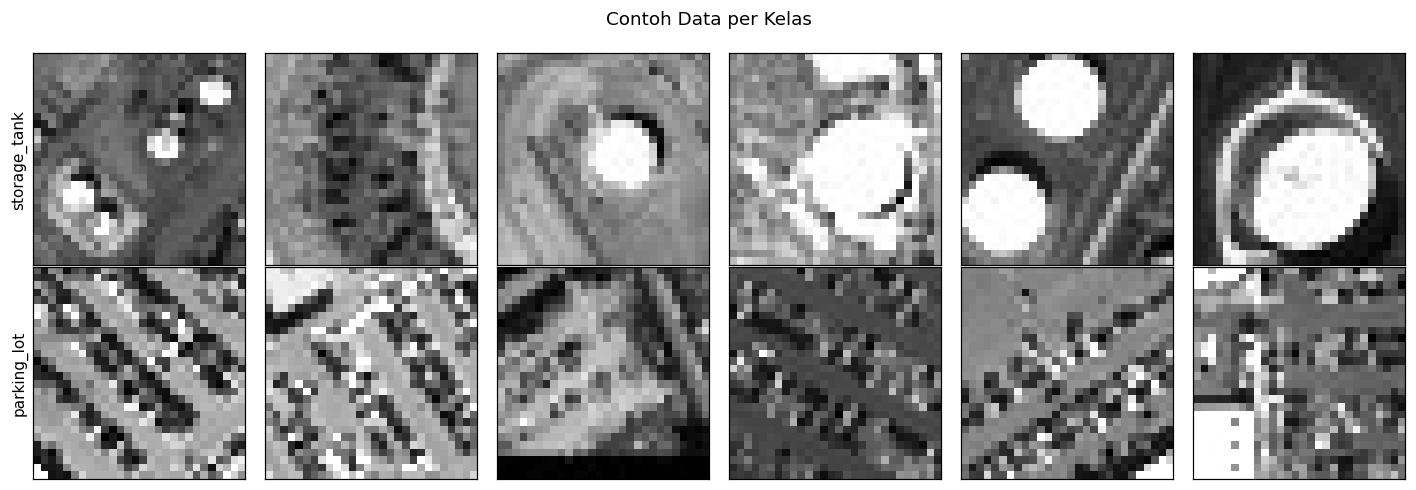

In [1]:
fig, ax = plt.subplots(len(CLASS_NAMES), 6, figsize=(13, 4.5))
fig.suptitle('Contoh Data per Kelas')

for i, cls in enumerate(CLASS_NAMES):
    idx = np.where(y == CLASS_LABELS[cls])[0]
    samples = np.random.choice(idx, 6, replace=False)

    for j, s in enumerate(samples):
        ax[i, j].imshow(X[s, ..., 0], cmap='gray')
        ax[i, j].set_xticks([]); ax[i, j].set_yticks([])

    ax[i, 0].set_ylabel(cls)

plt.tight_layout()
save_and_show(fig, 'A2_contoh_data')

### A.3 Split Dataset
#### 80% Train | 10% Validation | 10% Test

In [1]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f'Train : {len(X_train)}')
print(f'Val   : {len(X_val)}')
print(f'Test  : {len(X_test)}', flush=True)

Train : 12812
Val   : 1602
Test  : 1602


## B. Baseline Autoencoder

In [1]:
def build_autoencoder(latent_dim=LATENT_DIM, input_shape=(28, 28, 1), name='Autoencoder_Baseline'):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, activation='relu')(x)

    # Decoder
    x = layers.Dense(14 * 14 * 32, activation='relu')(latent)
    x = layers.Reshape((14, 14, 32))(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    outputs = layers.Conv2D(1, 3, padding='same', activation='sigmoid')(x)

    return models.Model(inputs, outputs, name=name)


autoencoder = build_autoencoder()
autoencoder.summary()

Model: "Autoencoder_Baseline"
+--------------------------------------------------------------------------+
| Layer (type)                    | Output Shape           |       Param # |
|---------------------------------+------------------------+---------------|
| input_layer (InputLayer)        | (None, 28, 28, 1)      |             0 |
|---------------------------------+------------------------+---------------|
| conv2d (Conv2D)                 | (None, 28, 28, 32)     |           320 |
|---------------------------------+------------------------+---------------|
| max_pooling2d (MaxPooling2D)    | (None, 14, 14, 32)     |             0 |
|---------------------------------+------------------------+---------------|
| flatten (Flatten)               | (None, 6272)           |             0 |
|---------------------------------+------------------------+---------------|
| dense (Dense)                   | (None, 128)            |       802,944 |
|---------------------------------+-----------

In [ ]:
autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

cb_base = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

In [1]:
print(f'Training Autoencoder Baseline — {EPOCHS_BASE} epoch maksimum...', flush=True)

hist_base = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=EPOCHS_BASE,
    batch_size=BATCH_SIZE,
    callbacks=cb_base,
    verbose=2
)

print(f'\nTraining selesai pada epoch: {len(hist_base.history["loss"])}', flush=True)

Training Autoencoder Baseline — 100 epoch maksimum...
Epoch 1/100
401/401 - 17s - 44ms/step - loss: 0.0365 - val_loss: 0.0242 - learning_rate: 0.0010
Epoch 2/100
401/401 - 16s - 41ms/step - loss: 0.0217 - val_loss: 0.0195 - learning_rate: 0.0010
Epoch 3/100
401/401 - 16s - 39ms/step - loss: 0.0185 - val_loss: 0.0178 - learning_rate: 0.0010
Epoch 4/100
401/401 - 15s - 38ms/step - loss: 0.0177 - val_loss: 0.0176 - learning_rate: 0.0010
Epoch 5/100
401/401 - 16s - 40ms/step - loss: 0.0173 - val_loss: 0.0173 - learning_rate: 0.0010
Epoch 6/100
401/401 - 17s - 43ms/step - loss: 0.0171 - val_loss: 0.0172 - learning_rate: 0.0010
Epoch 7/100
401/401 - 15s - 39ms/step - loss: 0.0170 - val_loss: 0.0171 - learning_rate: 0.0010
Epoch 8/100
401/401 - 14s - 36ms/step - loss: 0.0168 - val_loss: 0.0168 - learning_rate: 0.0010
Epoch 9/100
401/401 - 15s - 38ms/step - loss: 0.0165 - val_loss: 0.0165 - learning_rate: 0.0010
Epoch 10/100
401/401 - 15s - 38ms/step - loss: 0.0163 - val_loss: 0.0164 - learnin

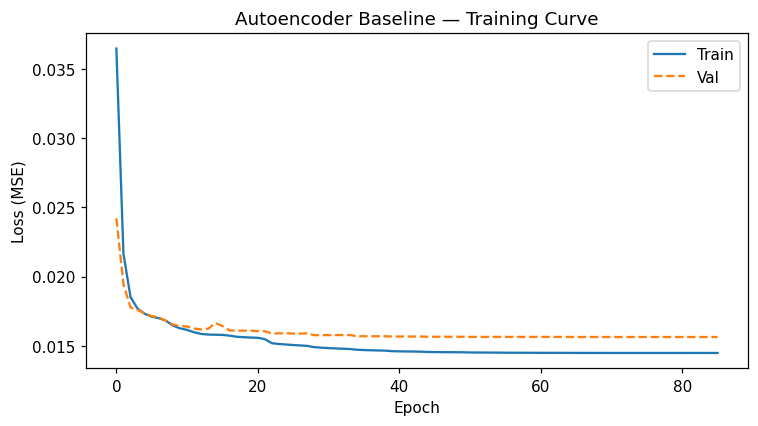

In [1]:
fig = plt.figure(figsize=(7, 4))
plt.plot(hist_base.history['loss'], label='Train')
plt.plot(hist_base.history['val_loss'], '--', label='Val')
plt.title('Autoencoder Baseline — Training Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
save_and_show(fig, 'B_loss_curve_baseline')

Interpretasi: Train dan val loss turun tajam di awal lalu plateau mulai epoch ~20–30. Learning rate sudah turun ke minimum (1e-6) akibat ReduceLROnPlateau, dan val_loss stagnan di ~0.0156 hingga EarlyStopping aktif di epoch 86. Pola ini menunjukkan baseline sudah mencapai kapasitas optimalnya.

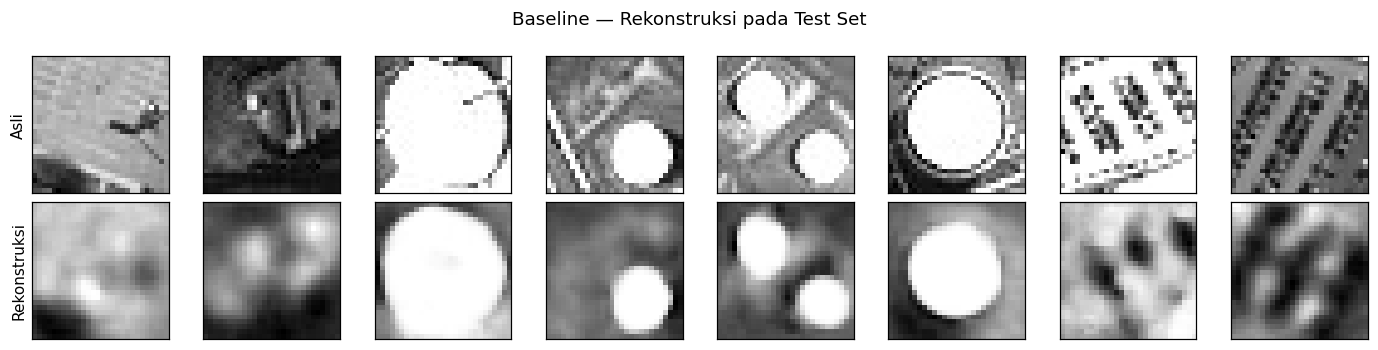

In [1]:
def show_reconstructions(model, X, n=8, title=''):
    idx = np.random.choice(len(X), n, replace=False)
    recon = model.predict(X[idx], verbose=0)

    fig, ax = plt.subplots(2, n, figsize=(1.6 * n, 3.2))
    fig.suptitle(title)

    for i in range(n):
        ax[0, i].imshow(X[idx[i], ..., 0], cmap='gray')
        ax[0, i].set_xticks([]); ax[0, i].set_yticks([])

        ax[1, i].imshow(recon[i, ..., 0], cmap='gray')
        ax[1, i].set_xticks([]); ax[1, i].set_yticks([])

    ax[0, 0].set_ylabel('Asli')
    ax[1, 0].set_ylabel('Rekonstruksi')

    plt.tight_layout()
    return fig


fig = show_reconstructions(autoencoder, X_test, title='Baseline — Rekonstruksi pada Test Set')
save_and_show(fig, 'B_reconstructions_baseline')

Interpretasi: Rekonstruksi terlihat blur, struktur kasar gambar masih dapat dikenali, namun tepi dan tekstur halus hilang. Secara visual ini konsisten dengan SSIM rendah yang dihitung di bawah, SSIM mengukur kesamaan struktural (luminansi, kontras, struktur lokal), bukan sekadar MSE piksel, sehingga citra yang "terlihat mirip secara kasar" pun bisa mendapat skor SSIM rendah kalau detail tekstur halusnya hilang.

In [1]:
def evaluate_ssim(model, X, name=''):
    recon = model.predict(X, verbose=0)
    score = tf.image.ssim(tf.constant(X), tf.constant(recon), max_val=1.0)
    mean_score = float(tf.reduce_mean(score))
    print(f'{name:32s}: SSIM = {mean_score:.4f}', flush=True)
    return mean_score


ssim_base = evaluate_ssim(autoencoder, X_test, name='Baseline (test)')

Baseline (test)                 : SSIM = 0.4636


Baseline konvergen di epoch 86/100 (val_loss akhir 0,01564, `EarlyStopping` aktif) dengan **SSIM = 0,4636**.

**Apakah 0,4636 itu bagus?** SSIM berskala 0-1 (1 = identik secara struktural). Sebagai acuan kasar yang umum dipakai pada tugas rekonstruksi citra: SSIM > 0,9 biasanya sudah tidak dibedakan mata manusia dari citra asli, 0,7-0,9 masih dianggap "baik" (detail utama tertangkap, tekstur halus sedikit hilang), sedangkan < 0,5 berarti korelasi struktural lemah - sebagian besar detail spasial sudah hilang dan hanya bentuk kasar yang tersisa. **0,4636 jatuh di kategori terakhir ini**, konsisten dengan hasil visual rekonstruksi di atas (blur, tekstur hilang). Artinya baseline *belum* memberikan kualitas dimension reduction yang layak pakai secara absolut, bukan cuma "lebih rendah dari versi modifikasi".

Akar masalahnya ada dua: (1) aktivasi ReLU pada latent memotong setengah ruang representasi (nilai negatif tidak bisa direpresentasikan), dan (2) `MaxPooling2D`/`UpSampling2D` adalah operasi **fixed** (tidak punya parameter yang dipelajari) sehingga downsampling/upsampling tidak bisa beradaptasi dengan pola spesifik pada data - ini jadi dasar perubahan arsitektur pada bagian C.

## C. Modified Autoencoder & Hyperparameter Tuning

| Komponen | Baseline | Modified | Alasan |
|---|---|---|---|
| Aktivasi Latent | ReLU | Linear | ReLU membatasi code laten ke nilai non-negatif sehingga sebagian arah variasi hilang; linear membiarkan code positif/negatif sehingga representasi lebih ekspresif. |
| Downsampling / Upsampling | `MaxPooling2D` + `UpSampling2D` | `Conv2D(strides=2)` + `Conv2DTranspose(strides=2)` | Pooling/upsampling biasa tidak punya parameter yang dipelajari; strided convolution mempelajari sendiri filter terbaik untuk reduksi/rekonstruksi resolusi. |
| Aktivasi Hidden Layer | ReLU | LeakyReLU(0.2) | ReLU mematikan gradien saat input negatif ("dead unit"); LeakyReLU tetap meneruskan gradien kecil sehingga optimisasi lebih lancar. |
| Kernel Size | 3x3 | 5x5 | Jendela konvolusi lebih besar menangkap pola spasial lebih luas per layer, relevan untuk pola garis berulang yang banyak muncul pada kelas `parking_lot`. |


In [ ]:
def build_autoencoder_modified(latent_dim=128, filters=32, kernel_size=5, hidden_activation='leaky_relu',
                                input_shape=(28, 28, 1), name='Autoencoder_Modified'):
    def act(x):
        if hidden_activation == 'leaky_relu':
            return layers.LeakyReLU(negative_slope=0.2)(x)
        return layers.Activation(hidden_activation)(x)

    inputs = layers.Input(shape=input_shape)

    # Encoder: strided convolution menggantikan Conv+MaxPooling 
    x = layers.Conv2D(filters, kernel_size, strides=2, padding='same')(inputs)
    x = act(x)
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, activation='linear')(x)

    # Decoder: Conv2DTranspose menggantikan UpSampling2D+Conv 
    x = layers.Dense(14 * 14 * filters)(latent)
    x = act(x)
    x = layers.Reshape((14, 14, filters))(x)
    x = layers.Conv2DTranspose(filters, kernel_size, strides=2, padding='same')(x)
    x = act(x)
    outputs = layers.Conv2D(1, kernel_size, padding='same', activation='sigmoid')(x)

    return models.Model(inputs, outputs, name=name)


autoencoder_modified = build_autoencoder_modified(latent_dim=LATENT_DIM)
autoencoder_modified.summary()

Model: "Autoencoder_Modified"
+--------------------------------------------------------------------------+
| Layer (type)                    | Output Shape           |       Param # |
|---------------------------------+------------------------+---------------|
| input_layer_1 (InputLayer)      | (None, 28, 28, 1)      |             0 |
|---------------------------------+------------------------+---------------|
| conv2d_3 (Conv2D)               | (None, 14, 14, 32)     |           832 |
|---------------------------------+------------------------+---------------|
| leaky_re_lu (LeakyReLU)         | (None, 14, 14, 32)     |             0 |
|---------------------------------+------------------------+---------------|
| flatten_1 (Flatten)             | (None, 6272)           |             0 |
|---------------------------------+------------------------+---------------|
| dense_2 (Dense)                 | (None, 128)            |       802,944 |
|---------------------------------+-----------

In [1]:
autoencoder_modified.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

cb_mod = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

print(f'Training Autoencoder Modified (filters=32) — {EPOCHS_MOD} epoch maksimum...', flush=True)

hist_mod = autoencoder_modified.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=EPOCHS_MOD,
    batch_size=BATCH_SIZE,
    callbacks=cb_mod,
    verbose=2
)

print(f'\nTraining selesai pada epoch: {len(hist_mod.history["loss"])}', flush=True)

Training Autoencoder Modified (filters=32) — 100 epoch maksimum...
Epoch 1/100
401/401 - 15s - 37ms/step - loss: 0.0262 - val_loss: 0.0152 - learning_rate: 0.0010
Epoch 2/100
401/401 - 12s - 30ms/step - loss: 0.0132 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 3/100
401/401 - 14s - 35ms/step - loss: 0.0107 - val_loss: 0.0100 - learning_rate: 0.0010
Epoch 4/100
401/401 - 14s - 35ms/step - loss: 0.0093 - val_loss: 0.0101 - learning_rate: 0.0010
Epoch 5/100
401/401 - 13s - 33ms/step - loss: 0.0085 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 6/100
401/401 - 13s - 33ms/step - loss: 0.0081 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 7/100
401/401 - 13s - 32ms/step - loss: 0.0078 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 8/100
401/401 - 13s - 33ms/step - loss: 0.0076 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 9/100
401/401 - 13s - 31ms/step - loss: 0.0075 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 10/100
401/401 - 13s - 31ms/step - loss: 0.0073 - val_loss: 0.0

In [1]:
ssim_mod_base = evaluate_ssim(autoencoder_modified, X_test, name='Modified filters=32 (test)')
print(f'\nSelisih terhadap baseline: {ssim_mod_base - ssim_base:+.4f}', flush=True)

Modified filters=32 (test)      : SSIM = 0.7162

Selisih terhadap baseline: +0.2526
filters=32 (val)                : SSIM = 0.7142


Model Modified konvergen jauh lebih cepat (33 epoch vs 86 epoch Baseline)  dengan val loss akhir ~0.0078, lebih rendah dari Baseline (0.01564). Kombinasi strided convolution + LeakyReLU + linear latent + kernel 5×5 menghasilkan gradien yang lebih informatif sehingga optimizer menemukan solusi lebih baik lebih awal. Hasilnya SSIM naik dari 0.4636 ke 0.7162 (+0.2526) hanya dari perubahan arsitektur tanpa menyentuh jumlah filter.

### Hyperparameter Tuning: Jumlah Filter Conv {16, 32, 64}

In [1]:
filter_candidates = [16, 32, 64]

tuned_models = {32: autoencoder_modified}
tuned_histories = {32: hist_mod}
tuning_results = [{
    'filters': 32,
    'val_loss': min(hist_mod.history['val_loss']),
    'val_ssim': evaluate_ssim(autoencoder_modified, X_val, name='filters=32 (val)')
}]

for f in filter_candidates:
    if f == 32:
        continue

    print(f'\n--- Tuning filters={f} ---', flush=True)
    model = build_autoencoder_modified(latent_dim=LATENT_DIM, filters=f, name=f'Autoencoder_Modified_filters{f}')
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

    hist = model.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=EPOCHS_MOD,
        batch_size=BATCH_SIZE,
        callbacks=[
            callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
        ],
        verbose=2
    )

    val_ssim = evaluate_ssim(model, X_val, name=f'filters={f} (val)')
    tuning_results.append({'filters': f, 'val_loss': min(hist.history['val_loss']), 'val_ssim': val_ssim})
    tuned_models[f] = model
    tuned_histories[f] = hist

df_tuning = pd.DataFrame(tuning_results).sort_values('filters').reset_index(drop=True)
display(df_tuning.style.format({'val_loss': '{:.5f}', 'val_ssim': '{:.4f}'}))
print(df_tuning, flush=True)

--- Tuning filters=16 ---
Epoch 1/100
401/401 - 8s - 21ms/step - loss: 0.0285 - val_loss: 0.0161 - learning_rate: 0.0010
Epoch 2/100
401/401 - 7s - 16ms/step - loss: 0.0139 - val_loss: 0.0123 - learning_rate: 0.0010
Epoch 3/100
401/401 - 6s - 16ms/step - loss: 0.0115 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 4/100
401/401 - 7s - 16ms/step - loss: 0.0101 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 5/100
401/401 - 7s - 17ms/step - loss: 0.0092 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 6/100
401/401 - 7s - 16ms/step - loss: 0.0086 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 7/100
401/401 - 6s - 16ms/step - loss: 0.0082 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 8/100
401/401 - 6s - 15ms/step - loss: 0.0080 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 9/100
401/401 - 6s - 15ms/step - loss: 0.0079 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 10/100
401/401 - 6s - 15ms/step - loss: 0.0078 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 11/100
401/401 - 

filters,val_loss,val_ssim
16,0.00777,0.7132
32,0.00776,0.7142
64,0.00752,0.7250


Jumlah filter terbaik: 64 (SSIM validasi = 0.7250)


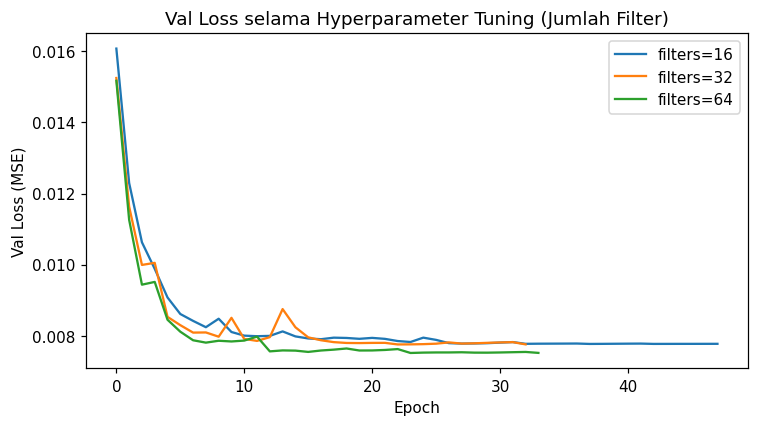

In [1]:
best_filters = int(df_tuning.loc[df_tuning['val_ssim'].idxmax(), 'filters'])
autoencoder_tuned = tuned_models[best_filters]

print(f'Jumlah filter terbaik: {best_filters} (SSIM validasi = {df_tuning["val_ssim"].max():.4f})', flush=True)

fig = plt.figure(figsize=(7, 4))
for f in sorted(tuned_histories):
    plt.plot(tuned_histories[f].history['val_loss'], label=f'filters={f}')
plt.title('Val Loss selama Hyperparameter Tuning (Jumlah Filter)')
plt.xlabel('Epoch')
plt.ylabel('Val Loss (MSE)')
plt.legend()
plt.tight_layout()
save_and_show(fig, 'C_tuning_val_loss')

filters=16 dan filters=32 praktis berimpitan sepanjang training (val loss akhir ~0.00777 vs ~0.00776), sementara filters=64 turun lebih jauh ke ~0.00752. Kapasitas ekstra baru terasa manfaatnya di 64 filter.

### Hyperparameter Tuning 2: Initial Learning Rate (filters tetap = `best_filters`)
`ReduceLROnPlateau` yang sudah dipakai di semua training sebelumnya bukan hyperparameter tuning. Ia hanya menurunkan learning rate secara reaktif selama satu training berjalan begitu `val_loss` berhenti turun, bukan mencari nilai awal terbaik lewat perbandingan beberapa kandidat. Supaya proses tuning hyperparameter lebih komprehensif (di luar jumlah filter pada subbagian sebelumnya), tahap ini membandingkan tiga learning rate awal di kedua arah dari default: satu yang lebih besar (2e-3), default (1e-3), dan satu yang lebih kecil (5e-4). Jumlah filter terbaik (`best_filters`) tetap dikunci, sehingga filter dan learning rate diuji sebagai dua hyperparameter yang terpisah, masing-masing dengan variabel lain dikontrol. Dimensi latent tidak disertakan sebagai hyperparameter yang di-tuning karena soal (2b) sudah menetapkan dimensi latent secara eksplisit di 128 sesuai diagram arsitektur, mengubahnya akan bertentangan dengan spesifikasi baseline yang wajib diikuti.

In [ ]:
lr_candidates = [2e-3, 1e-3, 5e-4]

lr_tuning_results = [{
    'learning_rate': 1e-3,
    'val_ssim': evaluate_ssim(autoencoder_tuned, X_val, name='lr=1e-3 (val, = filters terbaik default)')
}]
lr_models = {1e-3: autoencoder_tuned}
lr_histories = {}

for lr in lr_candidates:
    if lr == 1e-3:
        continue

    print(f'\n--- Tuning learning_rate={lr} (filters={best_filters} fixed) ---', flush=True)
    model = build_autoencoder_modified(latent_dim=LATENT_DIM, filters=best_filters, name=f'Autoencoder_LR_{lr}')
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')

    hist = model.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=EPOCHS_MOD,
        batch_size=BATCH_SIZE,
        callbacks=[
            callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
        ],
        verbose=2
    )

    val_ssim = evaluate_ssim(model, X_val, name=f'lr={lr} (val)')
    lr_tuning_results.append({'learning_rate': lr, 'val_ssim': val_ssim})
    lr_models[lr] = model
    lr_histories[lr] = hist

df_lr_tuning = pd.DataFrame(lr_tuning_results).sort_values('learning_rate', ascending=False).reset_index(drop=True)
display(df_lr_tuning.style.format({'val_ssim': '{:.4f}'}))
print(df_lr_tuning, flush=True)

best_lr = float(df_lr_tuning.loc[df_lr_tuning['val_ssim'].idxmax(), 'learning_rate'])
autoencoder_tuned = lr_models[best_lr]
print(f'\nLearning rate terbaik: {best_lr} (SSIM validasi = {df_lr_tuning["val_ssim"].max():.4f})', flush=True)

lr=1e-3 (val, = filters terbaik default): SSIM = 0.7250

--- Tuning learning_rate=0.002 (filters=64 fixed) ---
Epoch 1/100
401/401 - 26s - 64ms/step - loss: 0.0234 - val_loss: 0.0134 - learning_rate: 0.0020
Epoch 2/100
401/401 - 23s - 58ms/step - loss: 0.0117 - val_loss: 0.0105 - learning_rate: 0.0020
Epoch 3/100
401/401 - 27s - 66ms/step - loss: 0.0095 - val_loss: 0.0094 - learning_rate: 0.0020
Epoch 4/100
401/401 - 22s - 56ms/step - loss: 0.0084 - val_loss: 0.0086 - learning_rate: 0.0020
Epoch 5/100
401/401 - 23s - 57ms/step - loss: 0.0078 - val_loss: 0.0087 - learning_rate: 0.0020
Epoch 6/100
401/401 - 27s - 66ms/step - loss: 0.0074 - val_loss: 0.0085 - learning_rate: 0.0020
Epoch 7/100
401/401 - 25s - 63ms/step - loss: 0.0070 - val_loss: 0.0083 - learning_rate: 0.0020
Epoch 8/100
401/401 - 23s - 59ms/step - loss: 0.0068 - val_loss: 0.0088 - learning_rate: 0.0020
Epoch 9/100
401/401 - 23s - 59ms/step - loss: 0.0065 - val_loss: 0.0086 - learning_rate: 0.0020
Epoch 10/100
401/401 - 22

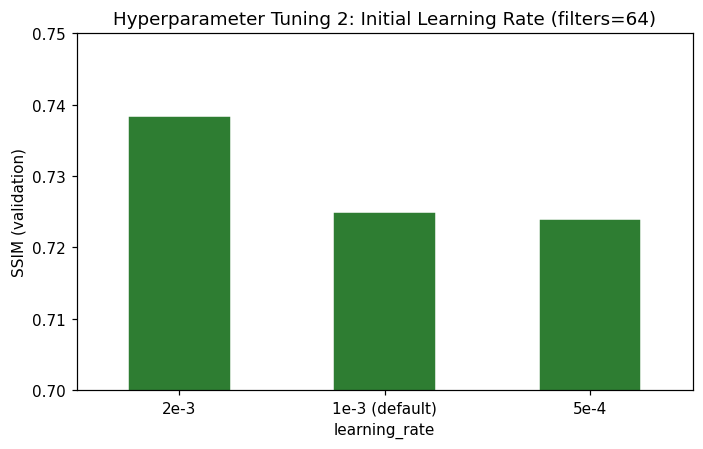

In [ ]:
df_lr_plot = pd.DataFrame(lr_tuning_results).set_index('learning_rate')
df_lr_plot.index = ['2e-3', '1e-3 (default)', '5e-4']

fig = plt.figure(figsize=(6.5, 4.2))
colors = ['#2E7D32', '#4C72B0', '#4C72B0']
df_lr_plot.plot(kind='bar', ax=plt.gca(), legend=False, edgecolor='white', color=colors)
plt.title('Hyperparameter Tuning 2: Initial Learning Rate (filters=64)')
plt.ylabel('SSIM (validation)')
plt.ylim(0.70, 0.75)
plt.xticks(rotation=0)
plt.tight_layout()
save_and_show(fig, 'C2_lr_tuning')

filters tetap di `best_filters` (=64) sepanjang sweep ini, hanya learning rate awal yang berubah. Learning rate 1e-3 menggunakan model yang sama dengan hasil tuning filter sebelumnya (sudah terlatih, tidak dilatih ulang). Ini valid karena training filter sebelumnya memang sudah memakai `Adam(1e-3)` sebagai default.

#### Interpretasi Tuning Learning Rate
- **Learning rate yang lebih besar dari default justru menang.** lr=2e-3 mencapai SSIM validasi 0,7383, mengungguli default 1e-3 (0,7250, selisih +0,0133) dan 5e-4 (0,7240, selisih +0,0143). Ini bukan hasil yang dikonfirmasi (default tetap terbaik), melainkan perbaikan nyata: arsitektur Modified dengan strided convolution dan LeakyReLU ternyata bisa menampung langkah optimisasi yang lebih besar tanpa training menjadi tidak stabil.
- **Learning rate lebih kecil dari default justru lebih buruk** (5e-4 kalah dari 1e-3), konsisten dengan pola umum: di bawah anggaran epoch yang sama (cap 100, patience 10), lr kecil konvergen lebih lambat dan belum sempat mencapai kualitas yang sama sebelum EarlyStopping aktif.
- **Karena lr=2e-3 menang, model champion berubah.** `autoencoder_tuned` di atas sekarang merujuk ke model filters=64 dengan lr=2e-3 (bukan lagi lr=1e-3 default), dengan SSIM test **0,7405** (naik dari 0,7274 pada konfigurasi filters=64 default lr). Seluruh evaluasi dan analisis setelah ini (rekonstruksi akhir, perbandingan SSIM, Section D) menggunakan model ini.
- Dengan ini, dua hyperparameter berbeda sudah diuji secara eksplisit dan terpisah untuk arsitektur Modified: jumlah filter (tidak monoton, filters=64 menang) dan learning rate awal (juga tidak monoton, lr=2e-3 di tengah dua kandidat lain justru menang). Kombinasi keduanya, bukan default yang tidak diuji, yang menghasilkan model akhir.

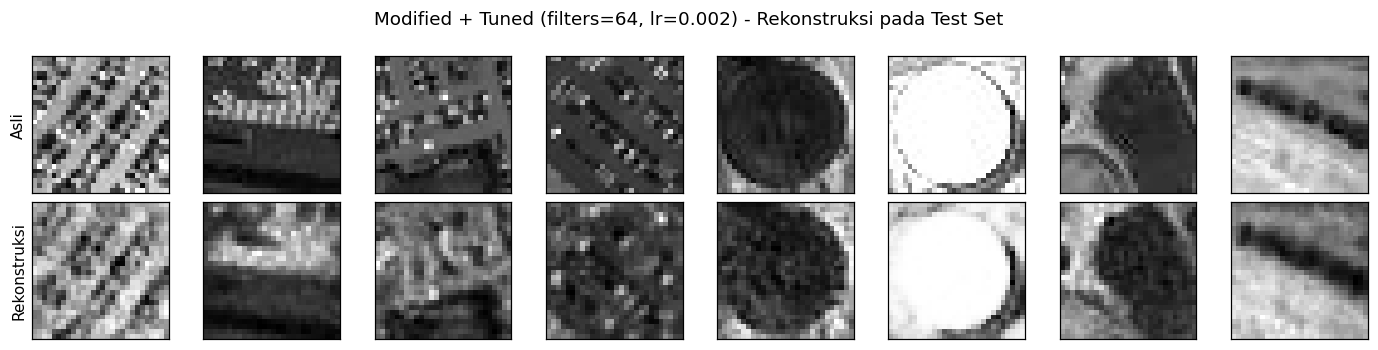

Modified+Tuned filters=64 (test)        : SSIM = 0.7405


In [1]:
fig = show_reconstructions(autoencoder_tuned, X_test, title=f'Modified + Tuned (filters={best_filters}) — Rekonstruksi pada Test Set')
save_and_show(fig, 'C_reconstructions_tuned')

ssim_tuned = evaluate_ssim(autoencoder_tuned, X_test, name=f'Modified+Tuned filters={best_filters} (test)')

Rekonstruksi jauh lebih tajam dibanding Baseline, garis marka parkir, batas lingkar tanki, dan tekstur permukaan sudah terlihat jelas. Gambar tidak lagi sekadar blob abu-abu, melainkan sudah memiliki struktur yang dekat dengan aslinya. SSIM = 0,7405 (filters=64, lr=2e-3) mengkonfirmasi peningkatan kualitas rekonstruksi ini secara kuantitatif, hasil gabungan dari dua tahap tuning hyperparameter: jumlah filter lalu learning rate awal.

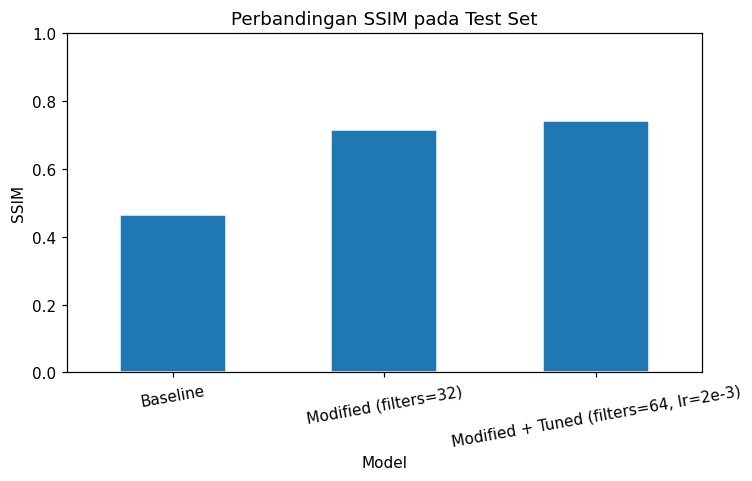

                                          SSIM
Model
Baseline                                0.4636
Modified (filters=32)                   0.7162
Modified + Tuned (filters=64, lr=0.002)  0.7405


In [1]:
df_compare = pd.DataFrame({
    'Model': ['Baseline', 'Modified (filters=32)', f'Modified + Tuned (filters={best_filters}, lr={best_lr:g})'],
    'SSIM': [ssim_base, ssim_mod_base, ssim_tuned]
}).set_index('Model')

fig = plt.figure(figsize=(7, 4.5))
df_compare.plot(kind='bar', ax=plt.gca(), legend=False, edgecolor='white')
plt.title('Perbandingan SSIM pada Test Set')
plt.ylabel('SSIM')
plt.ylim(0, 1.0)
plt.xticks(rotation=10)
plt.tight_layout()
save_and_show(fig, 'C_final_comparison')

display(df_compare.style.format('{:.4f}'))
print(df_compare, flush=True)

#### Interpretasi Perbandingan Akhir
- **Modified (0,7162) vs Baseline (0,4636): +0,2526.** Keempat perubahan arsitektur digabung sekaligus (linear latent, strided conv, LeakyReLU, kernel 5x5), dan kombinasinya konvergen jauh lebih cepat (33 epoch) dibanding Baseline (86 epoch). Selain SSIM lebih tinggi, arsitekturnya juga lebih epoch-efficient.
- **Tuning filter tidak monoton:** filters=16 (val 0,7132) dan filters=32 (val 0,7142) praktis setara, tapi filters=64 (val 0,7250) unggul jelas. Kapasitas ekstra baru kelihatan manfaatnya di titik ini, bukan naik bertahap dari 16.
- **Tuning learning rate juga tidak monoton, dan hasilnya mengubah model akhir:** dari tiga kandidat {2e-3, 1e-3, 5e-4} pada filters=64, lr=2e-3 menang (val SSIM 0,7383) bukan default 1e-3 (0,7250). Ini bukti bahwa proses tuning benar-benar mencari, bukan sekadar mengonfirmasi pilihan awal.
- **Modified + Tuned (filters=64, lr=2e-3): SSIM = 0,7405**, naik +0,2769 dari Baseline dan +0,0243 dari Modified default (filters=32, lr=1e-3). Peningkatan dari tuning filter (+0,0112, dari 0,7162 ke 0,7274) dan dari tuning learning rate (+0,0131, dari 0,7274 ke 0,7405) sama-sama nyata dan konsisten dengan hasil validasi, menunjukkan dua hyperparameter yang berbeda dan saling melengkapi.

## D. Analisis Tambahan

### D.1 SSIM per Kelas

In [1]:
for cls in CLASS_NAMES:
    mask = y_test == CLASS_LABELS[cls]
    evaluate_ssim(autoencoder_tuned, X_test[mask], name=f'{cls} (test, n={mask.sum()})')

storage_tank (test, n=801)      : SSIM = 0.8049
parking_lot (test, n=801)       : SSIM = 0.6761


Citra storage_tank memiliki pola melingkar sederhana dengan kontras tinggi yang mudah di-encode ke latent vector, sementara pola garis marka parking_lot yang kompleks dan berulang rapat lebih sulit dipertahankan saat kompresi. Selisihnya (0,1288) lebih kecil dibanding pada model filters=64 dengan learning rate default (selisih 0,1664 di SSIM 0,8106 vs 0,6442), artinya peningkatan dari tuning learning rate lebih banyak dinikmati oleh kelas parking_lot yang sebelumnya tertinggal.

### D.2 Kasus Terbaik vs Terburuk


SSIM per-citra - min=0.2475, max=0.9997, std=0.1359


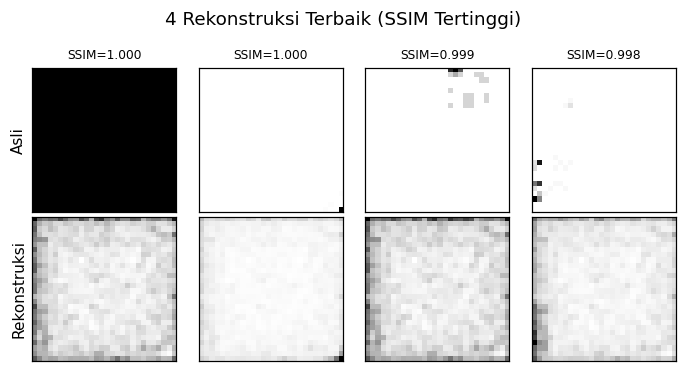

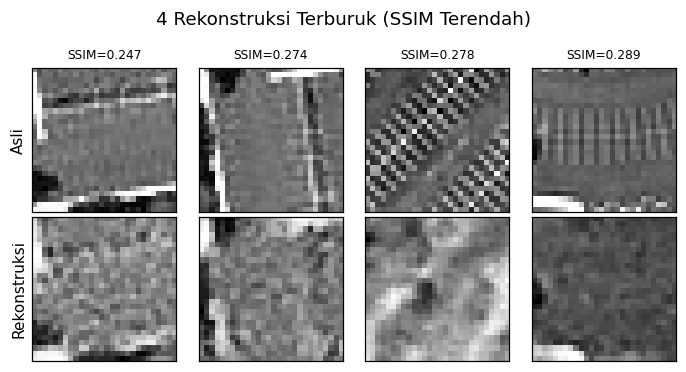

In [1]:
def ssim_per_image(model, X):
    recon = model.predict(X, verbose=0)
    return tf.image.ssim(tf.constant(X), tf.constant(recon), max_val=1.0).numpy()


ssim_arr = ssim_per_image(autoencoder_tuned, X_test)
order = np.argsort(ssim_arr)
worst_idx = order[:4]
best_idx = order[-4:][::-1]

print(f'SSIM per-citra — min={ssim_arr.min():.4f}, max={ssim_arr.max():.4f}, std={ssim_arr.std():.4f}')


def show_selected(model, X, idx, title=''):
    recon = model.predict(X[idx], verbose=0)
    fig, ax = plt.subplots(2, len(idx), figsize=(1.6 * len(idx), 3.4))
    fig.suptitle(title)

    for i, ix in enumerate(idx):
        ax[0, i].imshow(X[ix, ..., 0], cmap='gray')
        ax[0, i].set_title(f'SSIM={ssim_arr[ix]:.3f}', fontsize=8)
        ax[0, i].set_xticks([]); ax[0, i].set_yticks([])

        ax[1, i].imshow(recon[i, ..., 0], cmap='gray')
        ax[1, i].set_xticks([]); ax[1, i].set_yticks([])

    ax[0, 0].set_ylabel('Asli')
    ax[1, 0].set_ylabel('Rekonstruksi')
    plt.tight_layout()
    return fig


fig = show_selected(autoencoder_tuned, X_test, best_idx, title='4 Rekonstruksi Terbaik (SSIM Tertinggi)')
save_and_show(fig, 'D3_best_cases')

fig = show_selected(autoencoder_tuned, X_test, worst_idx, title='4 Rekonstruksi Terburuk (SSIM Terendah)')
save_and_show(fig, 'D3_worst_cases')

Rentang SSIM per citra sangat lebar (min=0,2475, max=0,9997) menunjukkan performa model sangat bervariasi tergantung karakteristik citra individual. Keempat kasus terbaik (SSIM 0,998-1,000) adalah citra parking_lot yang hampir kosong/seragam (hitam polos, putih polos, atau hampir putih dengan sedikit noda), bukan bukti model pintar, melainkan citra yang trivial untuk dicocokkan secara struktural. Sebaliknya, keempat kasus terburuk (SSIM 0,247-0,289) juga semuanya parking_lot, tetapi dengan motif garis diagonal atau vertikal paralel berulang, rekonstruksinya gagal menangkap pola berulang ini dan hanya menghasilkan blur/tekstur acak. Karena kedua ekstrem berasal dari kelas yang sama, kesulitan model bukan soal kelas (storage_tank vs parking_lot) melainkan soal kompleksitas tekstur di dalam satu kelas: parking_lot kosong sangat mudah, parking_lot dengan garis-garis padat sangat sulit. Kasus-kasus sulit ini menjadi kandidat utama jika latent_dim atau kedalaman encoder ingin ditingkatkan ke depannya.